# 🛰️ Mapping Your City From Above

> *Do you really know your city? How can you see changes in your neighborhood from above? …and what does that tell us?*

This notebook is Step 1 of our week: turning a single point on the map into real
satellite imagery and real census data for a neighborhood-sized piece of Mexico —
your hometown, Mérida, or anywhere else you're curious about.

**What you'll build in this notebook:**

1. **A square (or coastline-shaped) study area** around one latitude/longitude point you choose.
2. **Real satellite imagery** for that exact area, pulled live from the Sentinel-2 satellite.
3. **Census data** (population, housing) for that area, from Mexico's national statistics agency (INEGI).

Later this week you'll turn these observations into a *mental model* of your
urban-ecology system, and then into a *simulation* — a small video game where
different development choices change what you see from above.

**How this notebook works:** every section starts with a short explanation of
the *idea*, then gives you the code. Change the `LAT`/`LON`/`AREA_KM2` values
and re-run cells to explore a totally different place.


## Before you start (read this once)

- This notebook is designed to run in **Google Colab** — open it there so you don't need to install anything locally.
- The satellite imagery step needs internet access but **no account or API key**.
- The census step needs a couple of files that your instructor prepared ahead of time (Mexico's census website doesn't have a simple "give me this coordinate" button — more on that in Part 4). If those files aren't showing up, ask your instructor.


In [3]:
# Run this once per Colab session (takes ~30-60 seconds).
%pip install -q pystac-client rasterio geopandas shapely pyproj matplotlib openpyxl


In [2]:
import os
import io
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from shapely.geometry import Polygon, Point, box
from shapely.ops import transform as shapely_transform
from pyproj import Geod, Transformer
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from rasterio.mask import mask as rasterio_mask
from pystac_client import Client

plt.rcParams["figure.figsize"] = (7, 7)

# A local folder to cache big downloads so we don't re-fetch them every run.
CACHE_DIR = "data_cache"
os.makedirs(CACHE_DIR, exist_ok=True)


## Part 1 — From a point to a square

Latitude/longitude is a coordinate system measured in **degrees**, not meters.
That causes a subtlety: a degree of longitude covers *less* ground the further
you are from the equator, because lines of longitude squeeze together toward
the poles. So "0.02 degrees square" is not the same physical size everywhere
on Earth.

To build a square that is a genuine, real-world size (say, 2km × 2km) no
matter where in Mexico you click, we use **geodesic math**: starting at your
point, we walk a precise distance in meters along the Earth's surface at four
different compass bearings (northeast, southeast, southwest, northwest) to
find the square's corners.


In [4]:
# ---- Pick your spot! ----
# Try your own hometown, or anywhere in Mexico. A few starting examples:
#   Merida, Yucatan:      21.0190, -89.6237
#   Mexico City (CDMX):   19.4326, -99.1332
#   Progreso (coastal):   21.2833, -89.6633   <- try this one for Part 2!
LAT = 21.0190
LON = -89.6237
AREA_KM2 = 4.0   # ~2km x 2km neighborhood. Try 25.0 for a bigger district view.

SIDE_M = (AREA_KM2 ** 0.5) * 1000
print(f"Center point: ({LAT}, {LON})")
print(f"Square side length: {SIDE_M:.0f} meters  ->  area: {AREA_KM2} km²")


Center point: (21.019, -89.6237)
Square side length: 2000 meters  ->  area: 4.0 km²


Actual ground area of our square: 4.000 km²  (target was 4.0 km²)


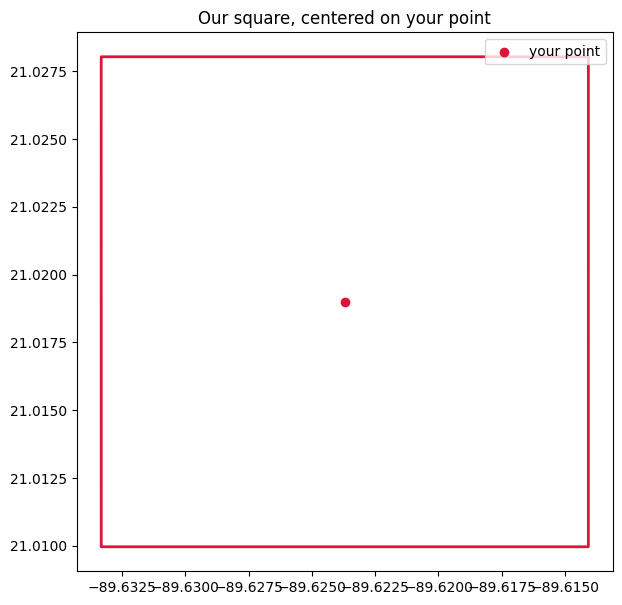

In [5]:
geod = Geod(ellps="WGS84")

def make_square(lon, lat, side_m):
    '''Build a geodesic square of `side_m` meters, centered on (lon, lat).

    We find each corner by walking the exact diagonal distance from the
    center at a compass bearing of 45/135/225/315 degrees (NE/SE/SW/NW).
    '''
    half_diagonal = (side_m / 2) * (2 ** 0.5)
    corners = []
    for bearing in (45, 135, 225, 315):
        corner_lon, corner_lat, _ = geod.fwd(lon, lat, bearing, half_diagonal)
        corners.append((corner_lon, corner_lat))
    return Polygon(corners)

square = make_square(LON, LAT, SIDE_M)

# geod.geometry_area_perimeter returns a signed area in m^2 -- sign depends on
# winding direction, so we take the absolute value.
area_m2, _ = geod.geometry_area_perimeter(square)
print(f"Actual ground area of our square: {abs(area_m2) / 1e6:.3f} km²  (target was {AREA_KM2} km²)")

square_gdf = gpd.GeoDataFrame({"id": [1]}, geometry=[square], crs="EPSG:4326")

fig, ax = plt.subplots()
square_gdf.plot(ax=ax, edgecolor="crimson", facecolor="none", linewidth=2)
ax.scatter([LON], [LAT], color="crimson", zorder=5, label="your point")
ax.set_title("Our square, centered on your point")
ax.legend()
plt.show()


## Part 2 — Coastlines aren't optional

If your point is inland, the square above *is* your study area. But if it's
near the coast, part of that square is ocean — not very useful for studying
urban ecology on land!

To fix this we need two more ideas:

- **A land polygon**: a dataset that knows the true shape of Mexico's coastline
  (we use [Natural Earth](https://www.naturalearthdata.com/), a free, widely-used
  geographic dataset).
- **A projected coordinate system (CRS)**: lat/lon degrees are great for
  storing locations, but bad for measuring *area* or doing precise geometry,
  because degrees distort near the poles and their real-world size changes
  with latitude. So before we cut our square down to just the land part, we
  temporarily switch to `EPSG:6372` — the official projected CRS Mexico's own
  statistics agency (INEGI) uses for exactly this kind of work — and switch
  back to lat/lon afterward.

The result may no longer be a perfect square — it could be a "weird"
multi-sided shape that follows the coastline. That's expected!


AOI area after coastline clip: 4.000 km² (original square: 4.0 km²)


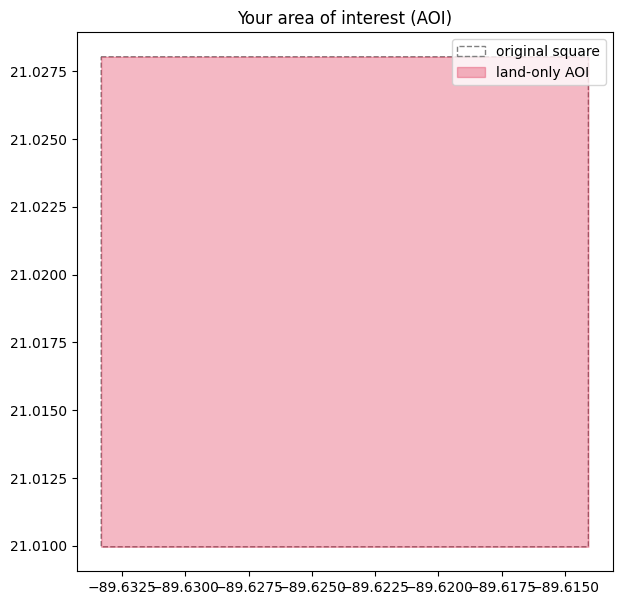

In [6]:
LAND_URL = "https://naciscdn.org/naturalearth/10m/physical/ne_10m_land.zip"
LAND_CACHE = os.path.join(CACHE_DIR, "ne_10m_land.zip")
if not os.path.exists(LAND_CACHE):
    print("Downloading world land polygons (one-time, ~3MB)...")
    urllib.request.urlretrieve(LAND_URL, LAND_CACHE)

land = gpd.read_file(LAND_CACHE)

MX_PROJECTED_CRS = "EPSG:6372"  # Mexico ITRF2008 / LCC


def clip_to_land(aoi_polygon_wgs84):
    '''Clip an AOI polygon to land only. Returns a GeoDataFrame in WGS84.

    Land polygons are huge (whole continents), so reprojecting the raw global
    layer into a Mexico-only CRS causes numerical errors. We first cut a
    small local piece out in WGS84 (safe, since we're not measuring area yet),
    *then* reproject just that small piece for the accurate intersection.
    '''
    aoi_gdf = gpd.GeoDataFrame({"id": [1]}, geometry=[aoi_polygon_wgs84], crs="EPSG:4326")
    local_bbox = box(*aoi_polygon_wgs84.buffer(0.3).bounds)
    local_land = gpd.clip(land, local_bbox)

    aoi_proj = aoi_gdf.to_crs(MX_PROJECTED_CRS)
    land_proj = local_land.to_crs(MX_PROJECTED_CRS)
    clipped = gpd.overlay(aoi_proj, land_proj, how="intersection")

    if len(clipped) == 0:
        raise ValueError("Your point is entirely in the ocean! Pick a different point.")
    return clipped.to_crs("EPSG:4326")


aoi_gdf = clip_to_land(square)
aoi_area_km2, _ = geod.geometry_area_perimeter(aoi_gdf.geometry.iloc[0])
print(f"AOI area after coastline clip: {abs(aoi_area_km2) / 1e6:.3f} km² (original square: {AREA_KM2} km²)")

fig, ax = plt.subplots()
square_gdf.plot(ax=ax, edgecolor="gray", facecolor="none", linestyle="--")
aoi_gdf.plot(ax=ax, edgecolor="crimson", facecolor="crimson", alpha=0.3)
ax.set_title("Your area of interest (AOI)")
# geopandas polygon plots don't support the `label=` kwarg for legends directly,
# so we build the legend entries by hand:
legend_handles = [
    Patch(edgecolor="gray", facecolor="none", linestyle="--", label="original square"),
    Patch(edgecolor="crimson", facecolor="crimson", alpha=0.3, label="land-only AOI"),
]
ax.legend(handles=legend_handles)
plt.show()


**Try it:** set `LAT, LON = 21.2833, -89.6633` (Progreso, a coastal town near
Mérida) back in Part 1, re-run everything down to here, and watch the square
turn into a coastline-hugging shape.

From here on, `aoi_gdf` — not the plain square — is our official study area.


## Part 3 — Getting satellite eyes on our AOI

We'll use the **Sentinel-2** satellite (European Space Agency), which images
almost all of Earth's land every few days at 10-meter resolution, split into
separate color **bands** (red, green, blue, near-infrared, and more).

We search for scenes using **STAC** ("SpatioTemporal Asset Catalog"), an open
standard for describing satellite imagery, hosted here for free by
[Element84 on AWS Open Data](https://earth-search.aws.element84.com) — no
account or API key required.

Each band is stored as a **Cloud-Optimized GeoTIFF (COG)** — a huge image
file (100+ million pixels) built so that software can download *just the
small piece it needs* over the network instead of the whole file. That's
exactly what we'll do: even though each scene covers a 110km x 110km tile,
we'll only pull the few hundred pixels covering our tiny AOI.


In [7]:
STAC_URL = "https://earth-search.aws.element84.com/v1"
stac_client = Client.open(STAC_URL)


def search_best_scene(aoi_polygon_wgs84, start="2024-01-01", end="2025-12-31", max_cloud=30):
    '''Search for the least-cloudy Sentinel-2 scene covering the AOI.'''
    search = stac_client.search(
        collections=["sentinel-2-l2a"],
        bbox=aoi_polygon_wgs84.bounds,
        datetime=f"{start}T00:00:00Z/{end}T00:00:00Z",
        max_items=50,
    )
    items = [i for i in search.items() if i.properties.get("eo:cloud_cover", 100) <= max_cloud]
    if not items:
        raise ValueError("No sufficiently clear scenes found -- try widening the date range or max_cloud.")
    items.sort(key=lambda i: i.properties["eo:cloud_cover"])
    return items[0]


best_item = search_best_scene(square)
print(f"Best scene: {best_item.id}")
print(f"Date: {best_item.properties['datetime']}")
print(f"Cloud cover: {best_item.properties['eo:cloud_cover']:.1f}%")


Best scene: S2C_15QZD_20251119_0_L2A
Date: 2025-11-19T16:37:54.015000Z
Cloud cover: 1.0%


In [8]:
def read_band_window(href, aoi_polygon_wgs84):
    '''Read only the pixels covering our AOI's bounding box from a remote COG.'''
    with rasterio.open(href) as src:
        left, bottom, right, top = transform_bounds("EPSG:4326", src.crs, *aoi_polygon_wgs84.bounds)
        window = from_bounds(left, bottom, right, top, transform=src.transform)
        data = src.read(1, window=window)
    return data


bands = {}
for band_name in ["red", "green", "blue", "nir"]:
    href = best_item.assets[band_name].href
    bands[band_name] = read_band_window(href, square)
    print(f"{band_name}: shape {bands[band_name].shape}, dtype {bands[band_name].dtype}")


red: shape (204, 204), dtype uint16
green: shape (204, 204), dtype uint16
blue: shape (204, 204), dtype uint16
nir: shape (204, 204), dtype uint16


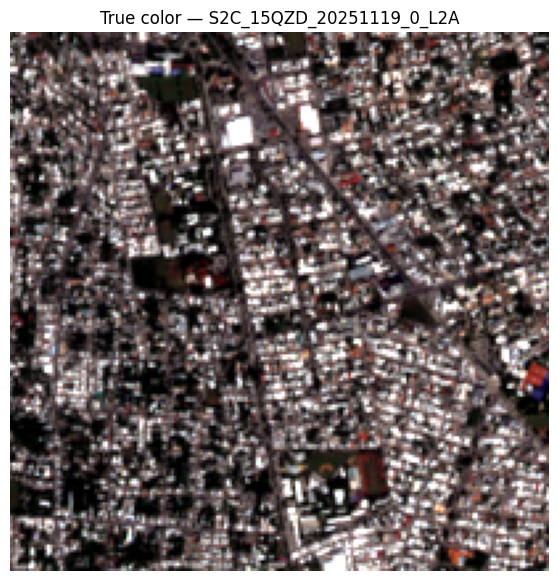

In [9]:
def normalize(band, low_pct=2, high_pct=98):
    '''Stretch pixel values to 0-1 for display, ignoring extreme outliers.'''
    lo, hi = np.percentile(band, [low_pct, high_pct])
    return np.clip((band.astype(float) - lo) / (hi - lo + 1e-6), 0, 1)


rgb = np.dstack([normalize(bands["red"]), normalize(bands["green"]), normalize(bands["blue"])])

plt.imshow(rgb)
plt.title(f"True color — {best_item.id}")
plt.axis("off")
plt.show()


### NDVI — measuring vegetation from space

Healthy plants strongly reflect near-infrared light but absorb red light for
photosynthesis. The **Normalized Difference Vegetation Index (NDVI)** turns
that fact into a single number per pixel:

$$\text{NDVI} = \frac{\text{NIR} - \text{Red}}{\text{NIR} + \text{Red}}$$

Values near **+1** mean dense vegetation, values near **0** mean bare
ground/pavement, and negative values usually mean water. This is one of the
core variables you'll use later this week to describe the urban-ecology
system in your mental model.


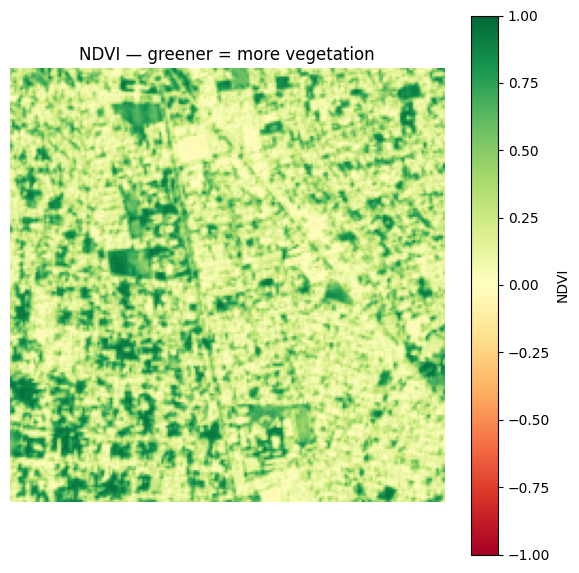

In [10]:
red = bands["red"].astype(float)
nir = bands["nir"].astype(float)
ndvi = (nir - red) / (nir + red + 1e-6)

plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI — greener = more vegetation")
plt.axis("off")
plt.show()


### Clipping the raster to your *actual* AOI shape

So far we've only used the AOI's rectangular bounding box. If your AOI got
clipped to a coastline shape in Part 2, we should mask out the ocean pixels
too, not just crop to a rectangle.


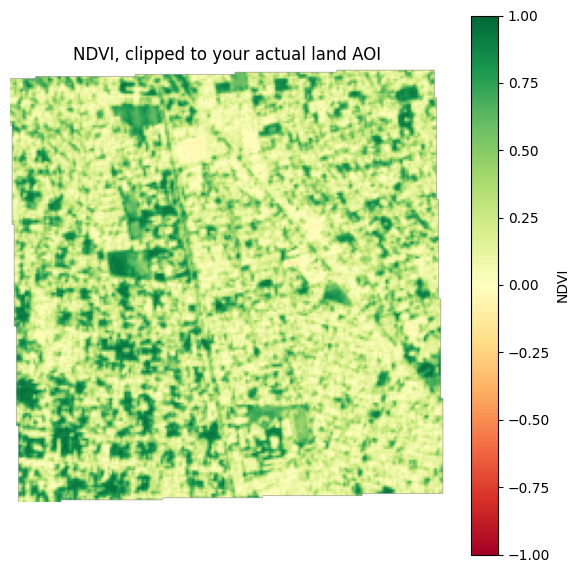

In [11]:
def read_band_masked(href, aoi_gdf_wgs84):
    '''Read only the pixels inside the AOI polygon (not just its bounding box).'''
    with rasterio.open(href) as src:
        aoi_native_crs = aoi_gdf_wgs84.to_crs(src.crs)
        out_image, _ = rasterio_mask(src, aoi_native_crs.geometry, crop=True, nodata=0)
    return out_image[0]


red_masked = read_band_masked(best_item.assets["red"].href, aoi_gdf).astype(float)
nir_masked = read_band_masked(best_item.assets["nir"].href, aoi_gdf).astype(float)
ndvi_masked = (nir_masked - red_masked) / (nir_masked + red_masked + 1e-6)
ndvi_masked = np.ma.masked_where(red_masked == 0, ndvi_masked)

plt.imshow(ndvi_masked, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI, clipped to your actual land AOI")
plt.axis("off")
plt.show()


## Part 3B — Comparing across time

This is where the "how can you see changes in your neighborhood... over
time?" question really comes alive. We can repeat everything above for
*multiple years* and compare.

Sentinel-2 (what we've used so far) only goes back to about 2017. For older
imagery we switch to **Landsat**, whose satellites have been flying since the
1980s. There's a catch: the *free, no-account* copy of Landsat on AWS turned
out to require a paid/authenticated account (a "requester-pays" bucket) — so
instead we pull historical Landsat scenes from **Microsoft's Planetary
Computer**, a different free catalog of the same public imagery. It needs one
extra step called `.sign()` on each image URL, but still **no account, no API
key, no cost**.

Sentinel-2 sees the world at 10-meter pixels; Landsat sees it at 30-meter
pixels. That means images from different years won't line up pixel-for-pixel
by default. To make an honest comparison (and a difference map), we
**resample** every year's image onto one common pixel grid before comparing.

One more real-world quirk you may run into: **Landsat 7** has had a broken
scan-line corrector since 2003, which leaves permanent diagonal gaps in every
image it takes. It's still useful data, but if a year's image looks
"striped," that's why — not a bug in this notebook. We prefer other Landsat
satellites when one's available for the same year.


In [12]:
%pip install -q planetary-computer


In [13]:
import planetary_computer
from rasterio.warp import reproject, Resampling

PC_STAC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
pc_client = Client.open(PC_STAC_URL)

SENTINEL2_START_YEAR = 2017  # Sentinel-2 L2A archive doesn't reliably start before this


def search_scene_for_year(aoi_polygon_wgs84, year, max_cloud=40):
    '''Find the least-cloudy scene for a given year.

    Uses Sentinel-2 (10m, via Earth Search) for `year >= SENTINEL2_START_YEAR`,
    and Landsat (30m, via Planetary Computer) for earlier years.
    '''
    bbox = aoi_polygon_wgs84.bounds
    date_range = f"{year}-01-01T00:00:00Z/{year}-12-31T00:00:00Z"

    if year >= SENTINEL2_START_YEAR:
        items = list(stac_client.search(
            collections=["sentinel-2-l2a"], bbox=bbox, datetime=date_range, max_items=50
        ).items())
        source = "sentinel-2"
    else:
        items = list(pc_client.search(
            collections=["landsat-c2-l2"], bbox=bbox, datetime=date_range, max_items=50
        ).items())
        source = "landsat"

    items = [i for i in items if i.properties.get("eo:cloud_cover", 100) <= max_cloud]
    if not items:
        raise ValueError(f"No sufficiently clear scenes found for {year}.")
    # Landsat 7's scan-line corrector permanently failed in 2003, leaving diagonal
    # gaps in every scene since. Prefer any other Landsat satellite when we can.
    items.sort(key=lambda i: (i.properties.get("platform") == "landsat-7", i.properties["eo:cloud_cover"]))
    return items[0], source


def read_window_full(href, aoi_polygon_wgs84):
    '''Like read_band_window, but also returns the transform/CRS needed to resample later.'''
    with rasterio.open(href) as src:
        left, bottom, right, top = transform_bounds("EPSG:4326", src.crs, *aoi_polygon_wgs84.bounds)
        window = from_bounds(left, bottom, right, top, transform=src.transform)
        data = src.read(1, window=window)
        transform = src.window_transform(window)
        return data, transform, src.crs


def ndvi_for_year(aoi_polygon_wgs84, year):
    '''Return (ndvi_array, transform, crs, item) for the best scene in `year`.'''
    item, source = search_scene_for_year(aoi_polygon_wgs84, year)
    if source == "sentinel-2":
        red_href = item.assets["red"].href
        nir_href = item.assets["nir"].href
    else:
        red_href = planetary_computer.sign(item.assets["red"].href)
        nir_href = planetary_computer.sign(item.assets["nir08"].href)

    red, transform, crs = read_window_full(red_href, aoi_polygon_wgs84)
    nir, _, _ = read_window_full(nir_href, aoi_polygon_wgs84)
    ndvi = (nir.astype(float) - red.astype(float)) / (nir.astype(float) + red.astype(float) + 1e-6)
    return ndvi, transform, crs, item


1996: LT05_L2SP_020045_19960104_02_T1  (cloud cover 0.0%)
2010: LT05_L2SP_020046_20100126_02_T1  (cloud cover 0.0%)
2024: S2A_16QBJ_20241124_0_L2A  (cloud cover 1.1%)


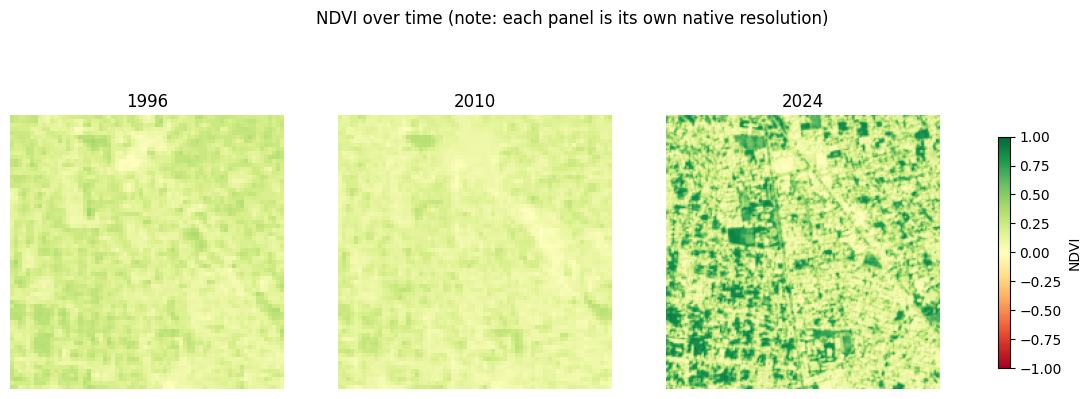

In [14]:
# ---- Pick the years you want to compare ----
YEARS_TO_COMPARE = [1996, 2010, 2024]

results = {}
for year in YEARS_TO_COMPARE:
    ndvi, transform, crs, item = ndvi_for_year(square, year)
    results[year] = {"ndvi": ndvi, "transform": transform, "crs": crs, "item": item}
    print(f"{year}: {item.id}  (cloud cover {item.properties['eo:cloud_cover']:.1f}%)")

fig, axes = plt.subplots(1, len(YEARS_TO_COMPARE), figsize=(5 * len(YEARS_TO_COMPARE), 5))
for ax, year in zip(axes, YEARS_TO_COMPARE):
    im = ax.imshow(results[year]["ndvi"], cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_title(str(year))
    ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.6, label="NDVI")
plt.suptitle("NDVI over time (note: each panel is its own native resolution)")
plt.show()


### Making it a fair comparison: resampling onto one grid

The panels above are useful for a quick look, but they're not pixel-aligned
(10m Sentinel-2 grid vs. 30m Landsat grid, and even slightly different UTM
zones). To compute an actual **change map** (e.g. "where did vegetation
increase or decrease between year A and year B?"), we resample every year
onto the *most recent* year's grid.


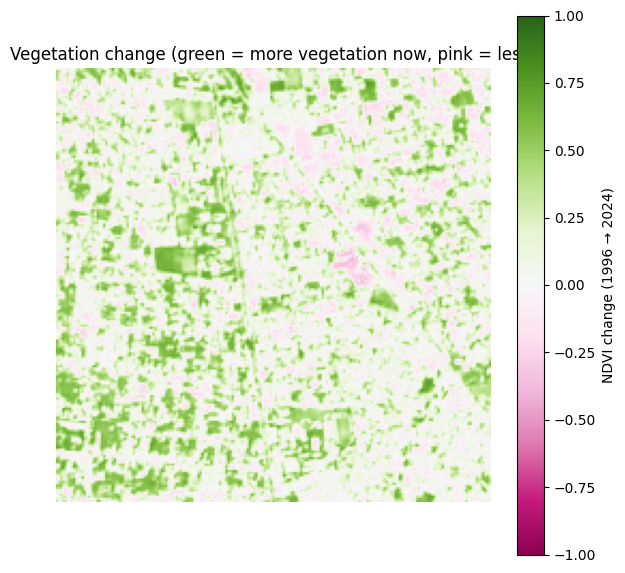

In [15]:
REFERENCE_YEAR = max(YEARS_TO_COMPARE)
ref = results[REFERENCE_YEAR]

aligned = {}
for year, r in results.items():
    if year == REFERENCE_YEAR:
        aligned[year] = r["ndvi"]
        continue
    dst = np.zeros(ref["ndvi"].shape, dtype=np.float32)
    reproject(
        source=r["ndvi"],
        destination=dst,
        src_transform=r["transform"], src_crs=r["crs"],
        dst_transform=ref["transform"], dst_crs=ref["crs"],
        resampling=Resampling.bilinear,
    )
    aligned[year] = dst

EARLIEST_YEAR = min(YEARS_TO_COMPARE)
change = aligned[REFERENCE_YEAR] - aligned[EARLIEST_YEAR]

plt.imshow(change, cmap="PiYG", vmin=-1, vmax=1)
plt.colorbar(label=f"NDVI change ({EARLIEST_YEAR} → {REFERENCE_YEAR})")
plt.title("Vegetation change (green = more vegetation now, pink = less)")
plt.axis("off")
plt.show()


## Part 4 — Census data: the human side of open data

Here's an important, very real lesson about working with open data: **not
every government agency has a simple API.** Mexico's national statistics
institute, INEGI, publishes incredibly detailed census data — all the way
down to the **manzana** (city block) level, nested inside **AGEB** (basic
geostatistical area) units — but there's no "give me data for this bounding
box" web service. Their site is built for a human clicking through a map
tool, not a script.

So this part works in three tiers, and it's normal (and a good discussion
topic!) if you land on tier 2 or 3:

1. **Live attempt** — we try downloading the population/housing indicators
   directly, using a URL pattern we found by inspecting INEGI's own download
   page. This *sometimes* works, but INEGI's servers sometimes block
   automated requests from scripts (not from a real web browser).
2. **Pre-staged files** — your instructor downloads each state's data once,
   ahead of time, by hand (through a real browser, which INEGI doesn't
   block), and shares the folder with the class (e.g. via Google Drive).
   This notebook checks for those files automatically.
3. **Manual instructions** — if neither of the above has what you need, the
   notebook prints the exact page to visit and what to click.

**One coverage nuance:** if your instructor collects this data for all 32
states, you'll have coverage of the *entire country* — but not at uniform
detail. INEGI only subdivides **urban** localities (roughly 2,500+ people, or
any municipal capital) down to individual **manzanas**. Everywhere else
(small rural communities) is only available as a single, larger **AGEB
rural** polygon with no block-level detail. So a point in a Mérida
neighborhood gets you manzana-level blocks; a point in a small rural village
gets you one bigger rural AGEB shape instead.

First, we figure out *which state* your AOI is in, since INEGI organizes
everything by state.


In [16]:
STATES_URL = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_1_states_provinces.zip"
STATES_CACHE = os.path.join(CACHE_DIR, "ne_10m_admin_1_states_provinces.zip")
if not os.path.exists(STATES_CACHE):
    print("Downloading Mexico state boundaries (one-time, ~15MB)...")
    urllib.request.urlretrieve(STATES_URL, STATES_CACHE)

mx_states = gpd.read_file(STATES_CACHE)
mx_states = mx_states[mx_states["iso_a2"] == "MX"]

# Map Natural Earth's ISO 3166-2 suffix to INEGI's official 2-digit state code.
INEGI_STATE_CODES = {
    "AGU": "01", "BCN": "02", "BCS": "03", "CAM": "04", "COA": "05",
    "COL": "06", "CHP": "07", "CHH": "08", "DIF": "09", "DUR": "10",
    "GUA": "11", "GRO": "12", "HID": "13", "JAL": "14", "MEX": "15",
    "MIC": "16", "MOR": "17", "NAY": "18", "NLE": "19", "OAX": "20",
    "PUE": "21", "QUE": "22", "ROO": "23", "SLP": "24", "SIN": "25",
    "SON": "26", "TAB": "27", "TAM": "28", "TLA": "29", "VER": "30",
    "YUC": "31", "ZAC": "32",
}


def find_state(lon, lat):
    '''Return (inegi_code, state_name) for the state containing (lon, lat).'''
    pt = Point(lon, lat)
    hit = mx_states[mx_states.contains(pt)]
    if len(hit) == 0:
        raise ValueError("That point doesn't fall inside any Mexican state -- check your LAT/LON.")
    row = hit.iloc[0]
    suffix = row["iso_3166_2"].split("-")[-1]
    return INEGI_STATE_CODES[suffix], row["name"]


state_code, state_name = find_state(LON, LAT)
print(f"Your AOI is in: {state_name} (INEGI state code {state_code})")


Your AOI is in: Yucatán (INEGI state code 31)


### Where this notebook looks for census data

Ask your instructor where the class's pre-staged census folder lives (a
shared Google Drive folder, most likely). Mount it below, or point
`CENSUS_DATA_DIR` at wherever the files ended up.

*(Instructors: see `INSTRUCTOR_SETUP.md` alongside this notebook for the
step-by-step download guide, including direct links for all 32 states.)*

Expected layout — one subfolder per state code, containing whatever INEGI
files your instructor collected for it:

```
census_data/
  01/   (Aguascalientes)
  09/   (Ciudad de Mexico)
  31/   (Yucatan)
  ...
```


In [17]:
# If you're in Colab and the instructor shared a Drive folder, uncomment these two lines:
# from google.colab import drive
# drive.mount("/content/drive")

CENSUS_DATA_DIR = "census_data"  # <- point this at the shared folder, e.g. "/content/drive/MyDrive/mx_camp/census_data"
STATE_DIR = os.path.join(CENSUS_DATA_DIR, state_code)
os.makedirs(CACHE_DIR, exist_ok=True)
print(f"Looking for pre-staged census data in: {STATE_DIR}")
print(f"Exists: {os.path.isdir(STATE_DIR)}")


Looking for pre-staged census data in: census_data/31
Exists: False


### Tier 1: try a live download

This is the URL pattern for INEGI's "Principales resultados por AGEB y
manzana urbana" population/housing indicators (attribute data only — no
map shapes). It's organized by state code, which is why we needed
`find_state()` above.


In [18]:
def try_live_census_download(state_code):
    '''Best-effort live download of INEGI's per-AGEB/manzana census indicators.

    Returns a DataFrame on success, or None if INEGI's server refuses the
    request (this happens -- their site sometimes blocks non-browser clients).
    '''
    url = f"https://www.inegi.org.mx/contenidos/programas/ccpv/iter/zip/resageburb20/resageburb_{state_code}xlsx20.zip"
    dest = os.path.join(CACHE_DIR, f"resageburb_{state_code}.zip")
    try:
        if not os.path.exists(dest):
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=20) as resp:
                with open(dest, "wb") as f:
                    f.write(resp.read())
        with zipfile.ZipFile(dest) as z:
            xlsx_name = [n for n in z.namelist() if n.lower().endswith(".xlsx")][0]
            with z.open(xlsx_name) as f:
                return pd.read_excel(io.BytesIO(f.read()))
    except Exception as e:
        print(f"Live download didn't work ({type(e).__name__}: {e}). That's OK -- falling back.")
        return None


census_df = try_live_census_download(state_code)
if census_df is not None:
    print(f"Loaded {len(census_df)} rows of census indicators live from INEGI.")
    print(census_df.columns[:10].tolist())


Loaded 40140 rows of census indicators live from INEGI.
['ENTIDAD', 'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'AGEB', 'MZA', 'POBTOT', 'POBFEM']


### Tier 2: pre-staged files, and Tier 3: instructions if nothing's there

Map *geometry* for AGEBs/manzanas (the actual polygon shapes to draw on a
map) has no reliable live-download path at all -- this has to come from your
instructor's pre-staged folder. The cell below looks for a shapefile there,
clips it to your AOI, and joins in whichever census indicators we found
above (from Tier 1) or finds inside the same folder (Tier 2).


In [19]:
def load_pre_staged_geometry(state_dir, state_code):
    '''Load the Manzana-level shapefile from the instructor's pre-staged folder.

    INEGI's "Marco Geoestadistico" bundle for a state contains many layers
    (state outline, municipios, roads, AGEBs, ...); the one we want is
    Manzana, named exactly "{state_code}m.shp" (e.g. "01m.shp" for
    Aguascalientes). It carries a ready-made CVEGEO key. If it's missing, we
    fall back to the coarser AGEB Urbana layer ("{state_code}a.shp"), which
    also has CVEGEO but one polygon per AGEB instead of per block.
    '''
    if not os.path.isdir(state_dir):
        return None
    for suffix in ["m.shp", "a.shp"]:
        target = f"{state_code}{suffix}".lower()
        matches = [f for f in os.listdir(state_dir) if f.lower() == target]
        if matches:
            gdf = gpd.read_file(os.path.join(state_dir, matches[0]))
            return gdf.to_crs("EPSG:4326")
    return None


census_geo = load_pre_staged_geometry(STATE_DIR, state_code)

if census_geo is None:
    print(f'''
No pre-staged geometry found for state {state_code} ({state_name}).

To fix this, your instructor (or you!) should follow INSTRUCTOR_SETUP.md:
grab the "Marco Geoestadistico, Censo de Poblacion y Vivienda 2020" product
for {state_name} from https://www.inegi.org.mx/temas/mg/, unzip it, and put
the conjunto_de_datos/ files directly in: {STATE_DIR}/
(look for a file literally named "{state_code}m.shp" among them)

For the matching population/housing numbers (if Tier 1 above didn't work),
download this file in a real browser (INEGI blocks scripted downloads, but
not your browser) and place it in the same folder:
  https://www.inegi.org.mx/contenidos/programas/ccpv/iter/zip/resageburb20/resageburb_{state_code}xlsx20.zip
''')
else:
    census_aoi = gpd.clip(census_geo, aoi_gdf)
    print(f"Clipped to AOI: {len(census_aoi)} AGEB/manzana polygons.")
    print("Available columns:", list(census_aoi.columns))



No pre-staged geometry found for state 31 (Yucatán).

To fix this, your instructor (or you!) should follow INSTRUCTOR_SETUP.md:
grab the "Marco Geoestadistico, Censo de Poblacion y Vivienda 2020" product
for Yucatán from https://www.inegi.org.mx/temas/mg/, unzip it, and put
the conjunto_de_datos/ files directly in: census_data/31/
(look for a file literally named "31m.shp" among them)

For the matching population/housing numbers (if Tier 1 above didn't work),
download this file in a real browser (INEGI blocks scripted downloads, but
not your browser) and place it in the same folder:
  https://www.inegi.org.mx/contenidos/programas/ccpv/iter/zip/resageburb20/resageburb_31xlsx20.zip



### Joining the shapes to the statistics

The geometry file and the statistics file are two separate products that
share no direct link *except* a common identifier code. INEGI's standard key
is called **CVEGEO**: a 16-character code built by concatenating

`ENTIDAD (2 digits) + MUNICIPIO (3 digits) + LOCALIDAD (4 digits) + AGEB (4 characters) + MANZANA (3 digits)`

The Manzana geometry file ships a ready-made `CVEGEO` column. The attribute
table ships the *pieces* as separate `ENTIDAD`/`MUN`/`LOC`/`AGEB`/`MZA`
columns (confirmed directly against a real downloaded copy of both files),
so we build the same code ourselves and match the two.

One more thing confirmed by checking real data: the attribute file also
contains **subtotal rows** (state totals, municipality totals, AGEB totals)
mixed in among the real block-level rows, marked by `MZA == 0`. We filter
those out first, or every subtotal row would (harmlessly, but confusingly)
fail to match any real block.


In [20]:
def find_column(df, keywords):
    '''Return the first column whose name contains any of the given keywords.'''
    if df is None:
        return None
    for col in df.columns:
        if any(kw in str(col).upper() for kw in keywords):
            return col
    return None


if census_geo is not None and census_df is not None:
    # The shapefile's own geostatistical key.
    geo_key_col = find_column(census_aoi, ["CVEGEO"])

    # The attribute table's identifier pieces.
    ent_col = find_column(census_df, ["ENTIDAD"])
    mun_col = find_column(census_df, ["MUN"])
    loc_col = find_column(census_df, ["LOC"])
    ageb_col = find_column(census_df, ["AGEB"])
    mza_col = find_column(census_df, ["MZA", "MANZANA"])

    print("Detected columns:")
    print(f"  geometry CVEGEO column: {geo_key_col}")
    print(f"  attribute ENTIDAD/MUN/LOC/AGEB/MZA columns: {ent_col}, {mun_col}, {loc_col}, {ageb_col}, {mza_col}")

    if geo_key_col and all([ent_col, mun_col, loc_col, ageb_col, mza_col]):
        # Drop subtotal/aggregate rows -- real manzana rows always have MZA != 0.
        block_rows = census_df[census_df[mza_col] != 0].copy()

        block_rows["CVEGEO_built"] = (
            block_rows[ent_col].astype(str).str.zfill(2)
            + block_rows[mun_col].astype(str).str.zfill(3)
            + block_rows[loc_col].astype(str).str.zfill(4)
            + block_rows[ageb_col].astype(str).str.zfill(4)
            + block_rows[mza_col].astype(str).str.zfill(3)
        )
        joined = census_aoi.merge(block_rows, left_on=geo_key_col, right_on="CVEGEO_built", how="left")
        matched = joined[find_column(joined, ["POBTOT"])].notna().sum() if find_column(joined, ["POBTOT"]) else 0
        print(f"Matched {matched} / {len(census_aoi)} polygons to population data "
              f"(unmatched ones are typically non-residential blocks with no census population)")

        pop_col = find_column(joined, ["POBTOT", "POB_TOT", "POBLACION"])
        if pop_col:
            joined.plot(column=pop_col, legend=True, cmap="viridis", missing_kwds={"color": "lightgrey"})
            plt.title("Total population by block")
            plt.axis("off")
            plt.show()
        else:
            print("Joined the tables, but couldn't auto-find a population column.")
            print("Explore `joined.columns` yourself and plot one you're interested in, e.g.:")
            print('  joined.plot(column="YOUR_COLUMN_HERE", legend=True)')
    else:
        print()
        print("Couldn't confidently auto-detect every join column -- INEGI may have")
        print("changed a column name. Inspect these yourself and set the *_col")
        print("variables above by hand:")
        print("  geometry columns:", list(census_aoi.columns))
        print("  attribute columns:", list(census_df.columns))
else:
    print("Need both `census_geo` (Tier 2/3) and `census_df` (Tier 1) to do the join.")
    print("Re-run the cells above once both are available.")


Need both `census_geo` (Tier 2/3) and `census_df` (Tier 1) to do the join.
Re-run the cells above once both are available.


## Wrap-up: what you have, and what's next

For your chosen point, you now have:

- `aoi_gdf` — your official study area (a square, or a coastline-clipped shape)
- `bands`, `ndvi_masked` — real Sentinel-2 imagery and a vegetation index, clipped to that area
- `census_aoi` (if available) — population/housing polygons for that area

Save these below so tomorrow's notebook (building the mental model) can pick
up right where you left off.


In [21]:
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

aoi_gdf.to_file(os.path.join(OUTPUT_DIR, "aoi.geojson"), driver="GeoJSON")
np.save(os.path.join(OUTPUT_DIR, "ndvi.npy"), ndvi_masked.filled(np.nan) if hasattr(ndvi_masked, "filled") else ndvi_masked)

if census_geo is not None:
    census_aoi.to_file(os.path.join(OUTPUT_DIR, "census_aoi.geojson"), driver="GeoJSON")

print(f"Saved outputs to ./{OUTPUT_DIR}/")


Saved outputs to ./outputs/
